In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/mesures_capteurs.csv")

In [3]:
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


**CONVERSION DE LA COLONNE DATE**
Actuellement "date_heure" est du texte (string) : "2026-01-22 04:00:00"
 pd.to_datetime() la convertit en vraie date/heure => indispensable pour bien tracer un graphique temporel

# ===== VERIFICATION =====
df.head()   # affiche les 5 premières lignes pour vérifier que tout est bien chargé

In [5]:
df["date_heure"] = pd.to_datetime(df["date_heure"])
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


# Partie 1 – Graphique linéaire (Line Plot)

Syntaxe
* plt.plot(x, y, label="...")   # trace la courbe
* plt.title("...")              # titre du graphique
* plt.xlabel("...")             # nom de l'axe X
* plt.ylabel("...")             # nom de l'axe Y
* plt.legend()                  # affiche la légende (utilise le "label")
* plt.grid(True)                # affiche la grille
* plt.show()                    # affiche le graphique

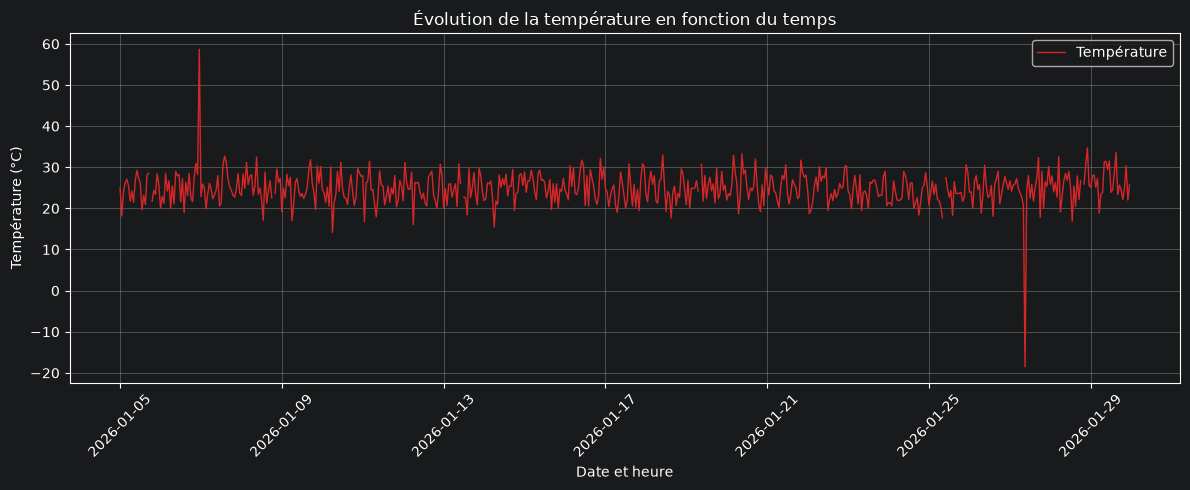

In [6]:

# ===== TRI DES DONNEES PAR DATE (important pour un line plot propre) =====
# Sans ça, la courbe peut "zigzaguer" si les lignes ne sont pas dans l'ordre chronologique
df_sorted = df.sort_values("date_heure")

# ===== CREATION DE LA FIGURE =====
plt.figure(figsize=(12, 5))   # figsize = (largeur, hauteur) en pouces, pour un graphique plus lisible

# ===== TRACE DE LA COURBE =====
plt.plot(
    df_sorted["date_heure"],     # axe X : le temps
    df_sorted["temperature"],    # axe Y : la température
    label="Température",         # texte affiché dans la légende
    color="tab:red",             # couleur de la courbe
    linewidth=1                  # épaisseur de la ligne
)

# ===== HABILLAGE DU GRAPHIQUE =====
plt.title("Évolution de la température en fonction du temps")  # titre principal
plt.xlabel("Date et heure")            # nom axe X
plt.ylabel("Température (°C)")         # nom axe Y
plt.legend()                           # affiche la légende (relie "tab:red" à "Température")
plt.grid(True)                         # ajoute une grille pour faciliter la lecture des valeurs

# ===== AJUSTEMENTS D'AFFICHAGE =====
plt.xticks(rotation=45)     # incline les dates sur l'axe X pour qu'elles ne se chevauchent pas
plt.tight_layout()          # ajuste automatiquement les marges pour que rien ne soit coupé

# ===== AFFICHAGE FINAL =====
plt.show()

**2) Identifier les valeurs anormales**

Regarde le graphique généré et repère :

des photos soudaines (température qui saute brutalement au-dessus/en dessous du reste)
des valeurs physiquement impossibles (ex : température négative extrême, ou très proche de 0 si ce n'est pas cohérent avec le contexte)
des trous dans la courbe (dus aux valeurs manquantes qu'on a vues : 6 NaN dans temperature)

In [7]:
# ===== BONUS : lister automatiquement les valeurs extrêmes pour t'aider à répondre =====
# On regarde les températures les plus hautes et les plus basses du dataset
print("Températures les plus élevées :")
print(df_sorted.nlargest(5, "temperature")[["date_heure", "batiment", "temperature"]])

print("\nTempératures les plus basses :")
print(df_sorted.nsmallest(5, "temperature")[["date_heure", "batiment", "temperature"]])

Températures les plus élevées :
             date_heure batiment  temperature
502 2026-01-06 23:00:00     B004        58.70
43  2026-01-28 22:00:00     B004        34.72
129 2026-01-29 15:00:00     B002        33.60
211 2026-01-20 09:00:00     B004        33.29
165 2026-01-18 10:00:00     B004        33.01

Températures les plus basses :
             date_heure batiment  temperature
487 2026-01-27 09:00:00     B004       -18.50
245 2026-01-10 06:00:00     B003        14.11
258 2026-01-14 06:00:00     B003        15.49
249 2026-01-12 06:00:00     B003        16.04
59  2026-01-11 01:00:00     B001        16.77


# Partie 2 – Diagramme en barres (Bar Chart)

Partie 2 – Diagramme en barres (Bar Chart)

Objectif : comparer la consommation énergétique moyenne entre les 4 bâtiments (B001, B002, B003, B004). Contrairement au line plot (évolution continue), le bar chart compare des catégories discrètes.

Syntaxe de base :

python
plt.bar(x, height)     # barres verticales
plt.barh(y, width)     # barres horizontales

**1) Calcul de consommation_batiment (consommation moyenne par bâtiment)**

In [8]:
# ===== CALCUL DE LA MOYENNE PAR BATIMENT =====
# groupby("batiment") regroupe toutes les lignes ayant le même bâtiment
# ["consommation"].mean() calcule la moyenne de consommation pour chaque groupe
consommation_batiment = df.groupby("batiment")["consommation"].mean()

# ===== VERIFICATION =====
print(consommation_batiment)

batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64


**2) Bar chart vertical — comparaison des bâtiments**

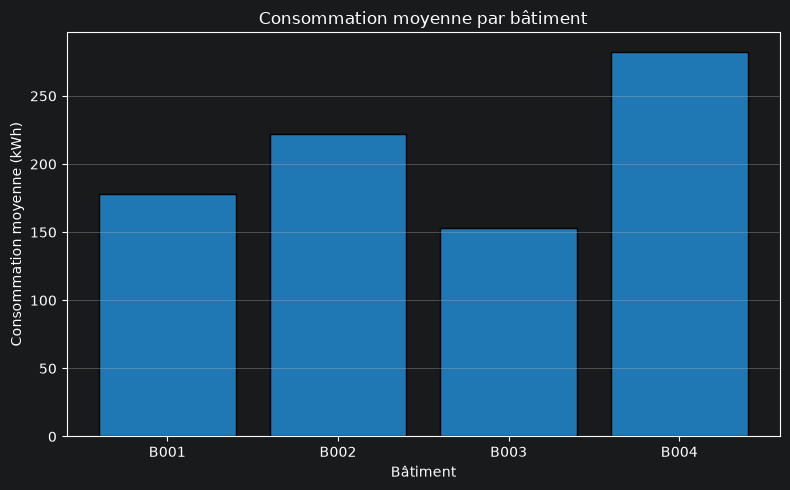

In [9]:
# ===== CREATION DE LA FIGURE =====
plt.figure(figsize=(8, 5))

# ===== TRACE DES BARRES VERTICALES =====
plt.bar(
    consommation_batiment.index,     # axe X : noms des bâtiments (B001, B002, B003, B004)
    consommation_batiment.values,    # axe Y : valeurs moyennes de consommation
    color="tab:blue",
    edgecolor="black"                # contour noir pour mieux distinguer chaque barre
)

# ===== HABILLAGE =====
plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Consommation moyenne (kWh)")
plt.grid(axis="y")   # grille horizontale seulement, utile pour lire les hauteurs de barres

plt.tight_layout()
plt.show()